<a href="https://colab.research.google.com/github/srushtinagaraju/Machine_Learning_1BM24CS424/blob/main/1BM24CS424_Lab-5_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = pd.read_csv("iris.csv")

X = data.iloc[:, :-1]   # features
y = data.iloc[:, -1]    # target

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Results (with lib)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
data = pd.read_csv("diabetes.csv")

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Results (with lib)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6948051948051948
Confusion Matrix:
 [[79 20]
 [27 28]]


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
data = pd.read_csv("iris.csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Euclidean Distance
def distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# KNN function
def knn_predict(X_train, y_train, x_test, k=5):
    distances = []

    for i in range(len(X_train)):
        d = distance(X_train[i], x_test)
        distances.append((d, y_train[i]))

    distances.sort(key=lambda x: x[0])
    neighbors = distances[:k]

    labels = [label for _, label in neighbors]
    return Counter(labels).most_common(1)[0][0]

# Predictions
predictions = []

for x in X_test:
    pred = knn_predict(X_train, y_train, x, k=5)
    predictions.append(pred)

# Results (without lib)
print("Accuracy:", accuracy_score(y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, predictions))

Accuracy: 0.9666666666666667
Confusion Matrix:
 [[11  0  0]
 [ 0 10  1]
 [ 0  0  8]]


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
data = pd.read_csv("diabetes.csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# -------- Feature Scaling (Standardization) --------
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# -------- Euclidean Distance --------
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# -------- KNN Function --------
def knn_predict(X_train, y_train, x_test, k=5):
    distances = []

    for i in range(len(X_train)):
        d = euclidean_distance(X_train[i], x_test)
        distances.append((d, y_train[i]))

    distances.sort(key=lambda x: x[0])
    neighbors = distances[:k]

    labels = [label for _, label in neighbors]
    prediction = Counter(labels).most_common(1)[0][0]

    return prediction

# -------- Predictions --------
predictions = []

for x in X_test:
    pred = knn_predict(X_train, y_train, x, k=5)
    predictions.append(pred)

#Results (without lib)
print("Accuracy:", accuracy_score(y_test, predictions))
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

Accuracy: 0.7012987012987013
Confusion Matrix:
[[83 19]
 [27 25]]


Best K: 9
Accuracy: 0.8852459016393442


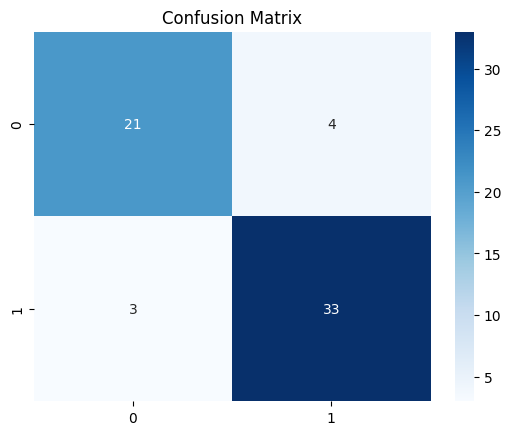

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.84      0.86        25
           1       0.89      0.92      0.90        36

    accuracy                           0.89        61
   macro avg       0.88      0.88      0.88        61
weighted avg       0.88      0.89      0.88        61



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv("heart.csv")

X = data.drop("target", axis=1)
y = data["target"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Find best K
scores = []
for k in range(1,21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

best_k = scores.index(max(scores)) + 1
print("Best K:", best_k)

# Train final model
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Classification Report (with lib)
print("Classification Report:\n", classification_report(y_test, y_pred))

Best K: 3
Accuracy: 0.9016393442622951


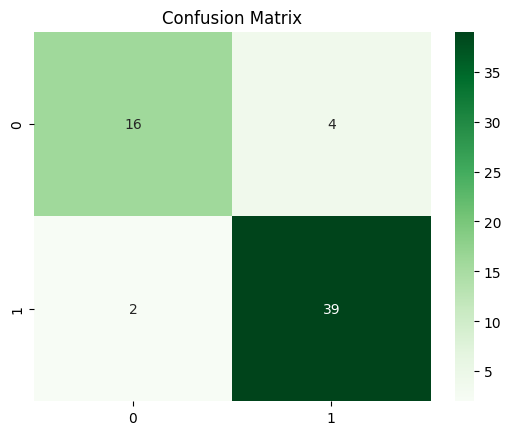

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.91      0.95      0.93        41

    accuracy                           0.90        61
   macro avg       0.90      0.88      0.89        61
weighted avg       0.90      0.90      0.90        61



In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = pd.read_csv("heart.csv")

X = data.drop("target", axis=1).values
y = data["target"].values

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Feature Scaling
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# Euclidean Distance
def distance(a,b):
    return np.sqrt(np.sum((a-b)**2))

# KNN Function
def knn_predict(X_train, y_train, test, k):

    distances = []

    for i in range(len(X_train)):
        d = distance(test, X_train[i])
        distances.append((d, y_train[i]))

    distances.sort()

    neighbors = distances[:k]
    labels = [n[1] for n in neighbors]

    return Counter(labels).most_common(1)[0][0]

# Find Best K
best_k = 1
best_acc = 0

for k in range(1,11):

    preds = []

    for x in X_test:
        preds.append(knn_predict(X_train, y_train, x, k))

    acc = accuracy_score(y_test, preds)

    if acc > best_acc:
        best_acc = acc
        best_k = k

print("Best K:", best_k)

# Final Prediction
predictions = []

for x in X_test:
    predictions.append(knn_predict(X_train, y_train, x, best_k))

# Accuracy
print("Accuracy:", accuracy_score(y_test, predictions))

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, cmap="Greens")
plt.title("Confusion Matrix")
plt.show()

# Classification Report (without lib)
print("Classification Report:\n", classification_report(y_test, predictions))